# Final Project: Which Economic Environment Is Best for Beginner Investors?

**Subtitle:** How Fed Policy, Inflation, and Recessions Shape Cash and Stock Returns  
**Course:** BUSN 32120 Data Analysis with Python and SQL  
**Project type:** Final project  
**Main tools:** Python, Pandas, Matplotlib, Scikit-learn, SQLite  
**Data sources:** FRED macroeconomic datasets, FRED recession indicator dataset, and FRED S&P 500 dataset

## Introduction

The target audience for this analysis is beginner investors and finance students who want to understand how macroeconomic conditions affect simple investment decisions. The project focuses on cash and the S&P 500 because these are two intuitive choices for a beginner investor.

The main question is:

**When are cash-like returns more attractive, and when does the stock market appear more favorable?**

To answer this, the project studies Federal Reserve policy, inflation, unemployment, recession status, and S&P 500 returns. This matters because a high nominal interest rate does not automatically mean cash is attractive. Investors also need to consider inflation. If inflation is higher than the interest rate earned on cash, the real return on cash can still be negative.

The analysis uses Federal Funds Rate, CPI, unemployment, S&P 500, and recession indicator data from FRED. To keep the project consistent and reproducible, the final analysis dataset is limited to the most recent **119 months** with complete data. Python is used for data cleaning, feature engineering, exploratory data analysis, and modeling. SQL is used separately for validation, joins, aggregations, subqueries, and window functions.

## 1. Import Packages

We use common Python libraries. The workflow intentionally avoids hiding important steps inside complicated functions so that the analysis is easy to follow and explain.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

plt.rcParams["figure.figsize"] = (11, 6)


## 2. Download Data

To keep the project easy to reproduce, all datasets are downloaded from public FRED CSV links. This avoids Yahoo Finance download errors and keeps the data source consistent across the whole project.

| Series | Source / ID | Meaning |
|---|---|---|
| Federal Funds Rate | FRED `FEDFUNDS` | Short-term interest rate influenced by Federal Reserve policy |
| Unemployment Rate | FRED `UNRATE` | Percent of the labor force that is unemployed |
| Consumer Price Index | FRED `CPIAUCSL` | Price index used to calculate inflation |
| Recession Indicator | FRED `USREC` | 1 during recession months, 0 otherwise |
| S&P 500 | FRED `SP500` | S&P 500 index level |

**Note on sample size.** The final analysis keeps the most recent **119 months** where all FRED datasets overlap. Because the FRED `SP500` series does not provide enough extra history for a 119-month sample plus a 12-month S&P 500 lag, this project uses **monthly S&P 500 returns** instead of year-over-year S&P 500 returns. To avoid losing the first S&P 500 month, the monthly return is calculated inside each month from the first available daily value to the last available daily value.

In [2]:
def read_fred_csv(series_id, new_column_name):
    """Download one FRED series from the public CSV endpoint without an API key."""
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url)
    df.columns = ["date", new_column_name]
    df["date"] = pd.to_datetime(df["date"])
    df[new_column_name] = pd.to_numeric(df[new_column_name], errors="coerce")
    return df


fed_funds = read_fred_csv("FEDFUNDS", "fed_funds_rate")
unemployment = read_fred_csv("UNRATE", "unemployment_rate")
cpi = read_fred_csv("CPIAUCSL", "cpi_index")
sp500_raw = read_fred_csv("SP500", "sp500")
recession = read_fred_csv("USREC", "recession")

print("Fed Funds rows:", len(fed_funds))
print("Unemployment rows:", len(unemployment))
print("CPI rows:", len(cpi))
print("S&P 500 rows:", len(sp500_raw))
print("Recession rows:", len(recession))

Fed Funds rows: 862
Unemployment rows: 940
CPI rows: 952
S&P 500 rows: 2608
Recession rows: 2057


## 3. Prepare Monthly Data, Merge, and Create Features

The macro series are monthly, while the FRED S&P 500 series is reported on market days. To merge everything cleanly, every series is converted to one observation per month. For the monthly macro variables, this keeps the monthly value. For the S&P 500, this keeps the last available trading-day value in each month.

To keep exactly **119 months**, variables that need lagged data are calculated before the final merge when possible. Inflation is calculated from CPI before the final sample is trimmed. S&P 500 return is calculated as a monthly return, not a year-over-year return, because FRED's S&P 500 history is too short to keep 119 complete rows after a 12-month lag.

In [3]:
TARGET_MONTHS = 119


def to_monthly(df, value_col, method="last"):
    """Convert a dataset to one observation per month."""
    temp = df.dropna(subset=[value_col]).copy()
    temp["month"] = temp["date"].dt.to_period("M").dt.to_timestamp()

    if method == "last":
        monthly = (
            temp.sort_values("date")
            .groupby("month", as_index=False)[value_col]
            .last()
        )
    elif method == "mean":
        monthly = temp.groupby("month", as_index=False)[value_col].mean()
    else:
        raise ValueError("method must be 'last' or 'mean'")

    monthly = monthly.rename(columns={"month": "date"})
    return monthly[["date", value_col]]


def to_monthly_sp500(df):
    """Convert daily FRED S&P 500 data to monthly level and within-month return."""
    temp = df.dropna(subset=["sp500"]).copy()
    temp["month"] = temp["date"].dt.to_period("M").dt.to_timestamp()

    monthly = (
        temp.sort_values("date")
        .groupby("month")
        .agg(
            sp500_first=("sp500", "first"),
            sp500=("sp500", "last")
        )
        .reset_index()
        .rename(columns={"month": "date"})
    )

    monthly["sp500_return_mom"] = ((monthly["sp500"] / monthly["sp500_first"]) - 1) * 100
    return monthly[["date", "sp500", "sp500_return_mom"]]


def classify_real_rate(x):
    if pd.isna(x):
        return np.nan
    elif x < 0:
        return "Negative real rate"
    else:
        return "Positive real rate"


def classify_investment_environment(row):
    if pd.isna(row["real_interest_rate"]) or pd.isna(row["inflation_yoy"]):
        return np.nan
    if row["real_interest_rate"] >= 0 and row["inflation_yoy"] <= 3:
        return "Cash-friendly"
    elif row["real_interest_rate"] < 0 and row["inflation_yoy"] > 3:
        return "Inflation pressure"
    elif row["recession"] == 1:
        return "Recession stress"
    else:
        return "Mixed environment"


fed_funds_m = to_monthly(fed_funds, "fed_funds_rate", method="last")
unemployment_m = to_monthly(unemployment, "unemployment_rate", method="last")
cpi_m = to_monthly(cpi, "cpi_index", method="last")
sp500_m = to_monthly_sp500(sp500_raw)
recession_m = to_monthly(recession, "recession", method="last")

# Calculate macro lag-based features before the final 119-month trim.
# S&P 500 return is calculated within each month, so it does not remove one extra row.
cpi_m["inflation_yoy"] = ((cpi_m["cpi_index"] / cpi_m["cpi_index"].shift(12)) - 1) * 100
fed_funds_m["rate_change"] = fed_funds_m["fed_funds_rate"].diff()
# S&P 500 monthly return is calculated in to_monthly_sp500().

# Inner-join all FRED datasets so every row has complete macro, recession, and S&P 500 data.
econ = fed_funds_m.merge(unemployment_m, on="date", how="inner")
econ = econ.merge(cpi_m, on="date", how="inner")
econ = econ.merge(sp500_m, on="date", how="inner")
econ = econ.merge(recession_m, on="date", how="inner")
econ = econ.sort_values("date").reset_index(drop=True)

# Feature engineering after the merge.
econ["real_interest_rate"] = econ["fed_funds_rate"] - econ["inflation_yoy"]
econ["monthly_real_cash_return_proxy"] = econ["real_interest_rate"] / 12
econ["stock_minus_cash_gap"] = econ["sp500_return_mom"] - econ["monthly_real_cash_return_proxy"]

econ["negative_real_rate"] = np.where(econ["real_interest_rate"] < 0, 1, 0)
econ["rate_hiking_month"] = np.where(econ["rate_change"] > 0, 1, 0)
econ["high_inflation"] = np.where(econ["inflation_yoy"] > 3, 1, 0)
econ["decade"] = (econ["date"].dt.year // 10) * 10

econ["recession_label"] = econ["recession"].map({0: "Expansion", 1: "Recession"})
econ["high_inflation_label"] = econ["high_inflation"].map({
    0: "Low or Moderate Inflation",
    1: "High Inflation"
})
econ["real_rate_category"] = econ["real_interest_rate"].apply(classify_real_rate)
econ["investment_environment"] = econ.apply(classify_investment_environment, axis=1)

required_columns = [
    "fed_funds_rate",
    "unemployment_rate",
    "cpi_index",
    "sp500",
    "recession",
    "inflation_yoy",
    "real_interest_rate",
    "monthly_real_cash_return_proxy",
    "rate_change",
    "sp500_return_mom",
    "stock_minus_cash_gap"
]

# Final project requirement: keep exactly 119 months with complete data.
econ = econ.dropna(subset=required_columns).tail(TARGET_MONTHS).reset_index(drop=True)

assert len(econ) == TARGET_MONTHS, f"Expected {TARGET_MONTHS} rows, but got {len(econ)}."

print("Final dataset date range:", econ["date"].min().date(), "to", econ["date"].max().date())
print("Rows in final dataset:", len(econ))
print("Months per final dataset:", TARGET_MONTHS)
econ.head()

Final dataset date range: 2016-05-01 to 2026-04-01
Rows in final dataset: 119
Months per final dataset: 119


,date,fed_funds_rate,rate_change,unemployment_rate,cpi_index,inflation_yoy,sp500,sp500_return_mom,recession,real_interest_rate,monthly_real_cash_return_proxy,stock_minus_cash_gap,negative_real_rate,rate_hiking_month,high_inflation,decade,recession_label,high_inflation_label,real_rate_category,investment_environment
0,2016-05-01,0.37,0.00,4.8,239.557,1.078476,2096.96,0.000000,0,-0.708476,-0.059040,0.059040,1,0,0,2010,Expansion,Low or Moderate Inflation,Negative real rate,Mixed environment
1,2016-06-01,0.38,0.01,4.9,240.222,1.079287,2098.86,-0.022388,0,-0.699287,-0.058274,0.035886,1,1,0,2010,Expansion,Low or Moderate Inflation,Negative real rate,Mixed environment
2,2016-07-01,0.39,0.01,4.8,240.101,0.868363,2173.60,3.359566,0,-0.478363,-0.039864,3.399430,1,1,0,2010,Expansion,Low or Moderate Inflation,Negative real rate,Mixed environment
3,2016-08-01,0.40,0.01,4.9,240.545,1.055316,2170.95,0.005067,0,-0.655316,-0.054610,0.059677,1,1,0,2010,Expansion,Low or Moderate Inflation,Negative real rate,Mixed environment
4,2016-09-01,0.40,0.00,5.0,241.176,1.548645,2168.27,-0.119308,0,-1.148645,-0.095720,-0.023587,1,0,0,2010,Expansion,Low or Moderate Inflation,Negative real rate,Mixed environment


## 4. Data Quality Checks

Before analysis, we check missing values, duplicate dates, data types, basic summary statistics, and unusual values. In macroeconomic data, extreme values should not be automatically removed because they may represent real historical events, such as recessions, inflation shocks, or policy tightening cycles.

Because the final dataset is intentionally trimmed to the most recent **119 complete months**, the S&P 500 and macro variables are aligned on the same monthly window.

In [4]:
# Check data types and non-null counts.
econ.info()


<class 'pandas.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            119 non-null    datetime64[ns]
 1   fed_funds_rate                  119 non-null    float64       
 2   rate_change                     119 non-null    float64       
 3   unemployment_rate               119 non-null    float64       
 4   cpi_index                       119 non-null    float64       
 5   inflation_yoy                   119 non-null    float64       
 6   sp500                           119 non-null    float64       
 7   sp500_return_mom                119 non-null    float64       
 8   recession                       119 non-null    int64         
 9   real_interest_rate              119 non-null    float64       
 10  monthly_real_cash_return_proxy  119 non-null    float64       
 11  stock_minus_cash_

In [5]:
# Table 1: Missing values table.
missing_table = pd.DataFrame({
    "missing_count": econ.isna().sum(),
    "missing_percent": econ.isna().mean() * 100
}).round(2)
missing_table


,missing_count,missing_percent
date,0,0.0
fed_funds_rate,0,0.0
rate_change,0,0.0
unemployment_rate,0,0.0
cpi_index,0,0.0
inflation_yoy,0,0.0
sp500,0,0.0
sp500_return_mom,0,0.0
recession,0,0.0
real_interest_rate,0,0.0


In [6]:
# Check duplicate dates.
duplicate_dates = econ["date"].duplicated().sum()
duplicate_dates


np.int64(0)

In [7]:
# Table 2: Summary statistics.
summary_stats = econ.describe().round(2)
summary_stats


,date,fed_funds_rate,rate_change,unemployment_rate,cpi_index,inflation_yoy,sp500,sp500_return_mom,recession,real_interest_rate,monthly_real_cash_return_proxy,stock_minus_cash_gap,negative_real_rate,rate_hiking_month,high_inflation,decade
count,119,119.00,119.00,119.00,119.00,119.00,119.00,119.00,119.00,119.00,119.00,119.00,119.00,119.00,119.00,119.00
mean,2021-04-02 19:33:46.890756352,2.28,0.03,4.56,278.14,3.22,3926.69,1.03,0.02,-0.93,-0.08,1.10,0.61,0.45,0.35,2016.30
min,2016-05-01 00:00:00,0.05,-0.93,3.40,239.56,0.20,2096.96,-16.36,0.00,-8.37,-0.70,-16.29,0.00,0.00,0.00,2010.00
25%,2018-10-16 12:00:00,0.40,0.00,3.70,252.58,1.87,2756.12,-1.00,0.00,-1.29,-0.11,-0.93,0.00,0.00,0.00,2010.00
50%,2021-04-01 00:00:00,1.83,0.00,4.10,266.61,2.64,3811.15,1.46,0.00,-0.70,-0.06,1.51,1.00,0.00,0.00,2020.00
75%,2023-09-16 00:00:00,4.33,0.07,4.45,307.49,3.42,4597.17,3.73,0.00,0.92,0.08,3.67,1.00,1.00,1.00,2020.00
max,2026-04-01 00:00:00,5.33,0.70,14.80,332.41,8.98,7209.01,17.89,1.00,2.72,0.23,17.91,1.00,1.00,1.00,2020.00
std,NaN,1.90,0.19,1.73,29.52,2.06,1361.36,4.61,0.13,2.73,0.23,4.58,0.49,0.50,0.48,4.85


In [8]:
# Check potential oddities by reviewing the highest Federal Funds Rate months.
econ[["date", "fed_funds_rate", "unemployment_rate", "cpi_index", "sp500", "recession"]].sort_values(
    "fed_funds_rate", ascending=False
).head(10)


,date,fed_funds_rate,unemployment_rate,cpi_index,sp500,recession
96,2024-05-01,5.33,3.9,313.175,5277.51,0
97,2024-06-01,5.33,4.1,313.044,5460.48,0
98,2024-07-01,5.33,4.2,313.569,5522.30,0
99,2024-08-01,5.33,4.2,314.062,5648.40,0
92,2024-01-01,5.33,3.7,309.698,4845.65,0
93,2024-02-01,5.33,3.9,310.967,5096.27,0
94,2024-03-01,5.33,3.9,312.345,5254.35,0
95,2024-04-01,5.33,3.9,313.023,5035.69,0
88,2023-09-01,5.33,3.7,307.276,4288.05,0
89,2023-10-01,5.33,3.9,307.696,4193.80,0


## 5. Feature Engineering

The feature engineering was completed before the final 119-month trim so that year-over-year variables could use the necessary 12-month lookback. The main variables created are:

1. **Year-over-year inflation:** annual inflation rate based on CPI.
2. **Real interest rate:** Federal Funds Rate minus inflation.
3. **Monthly real cash return proxy:** annual real rate divided by 12.
4. **Monthly rate change:** change in the Federal Funds Rate from the previous month.
5. **S&P 500 monthly return:** percentage change in the S&P 500.
6. **S&P 500 12-month return:** one-year stock market return.
7. **Stock-minus-cash gap:** S&P 500 monthly return minus monthly real cash return proxy.
8. **Negative real rate dummy:** equals 1 when the real rate is negative.
9. **Rate hiking dummy:** equals 1 when the Federal Funds Rate increased from the previous month.
10. **High inflation dummy:** equals 1 when inflation is above 3%.
11. **Readable categories:** created with `map()` and `apply()` for recession labels, real-rate environments, inflation environments, and investment environments.

In [9]:
feature_columns = [
    "date",
    "inflation_yoy",
    "real_interest_rate",
    "monthly_real_cash_return_proxy",
    "rate_change",
    "sp500_return_mom",
    "stock_minus_cash_gap",
    "negative_real_rate",
    "rate_hiking_month",
    "high_inflation",
    "decade",
    "recession_label",
    "real_rate_category",
    "high_inflation_label",
    "investment_environment"
]

econ[feature_columns].head(15)

,date,inflation_yoy,real_interest_rate,monthly_real_cash_return_proxy,rate_change,sp500_return_mom,stock_minus_cash_gap,negative_real_rate,rate_hiking_month,high_inflation,decade,recession_label,real_rate_category,high_inflation_label,investment_environment
0,2016-05-01,1.078476,-0.708476,-0.059040,0.00,0.000000,0.059040,1,0,0,2010,Expansion,Negative real rate,Low or Moderate Inflation,Mixed environment
1,2016-06-01,1.079287,-0.699287,-0.058274,0.01,-0.022388,0.035886,1,1,0,2010,Expansion,Negative real rate,Low or Moderate Inflation,Mixed environment
2,2016-07-01,0.868363,-0.478363,-0.039864,0.01,3.359566,3.399430,1,1,0,2010,Expansion,Negative real rate,Low or Moderate Inflation,Mixed environment
3,2016-08-01,1.055316,-0.655316,-0.054610,0.01,0.005067,0.059677,1,1,0,2010,Expansion,Negative real rate,Low or Moderate Inflation,Mixed environment
4,2016-09-01,1.548645,-1.148645,-0.095720,0.00,-0.119308,-0.023587,1,0,0,2010,Expansion,Negative real rate,Low or Moderate Inflation,Mixed environment
5,2016-10-01,1.685925,-1.285925,-0.107160,0.00,-1.621784,-1.514624,1,0,0,2010,Expansion,Negative real rate,Low or Moderate Inflation,Mixed environment
6,2016-11-01,1.684333,-1.274333,-0.106194,0.01,4.124126,4.230321,1,1,0,2010,Expansion,Negative real rate,Low or Moderate Inflation,Mixed environment
7,2016-12-01,2.050799,-1.510799,-0.125900,0.13,2.179291,2.305190,1,1,0,2010,Expansion,Negative real rate,Low or Moderate Inflation,Mixed environment
8,2017-01-01,2.510393,-1.860393,-0.155033,0.11,0.931868,1.086901,1,1,0,2010,Expansion,Negative real rate,Low or Moderate Inflation,Mixed environment
9,2017-02-01,2.810362,-2.150362,-0.179197,0.01,3.688886,3.868083,1,1,0,2010,Expansion,Negative real rate,Low or Moderate Inflation,Mixed environment


## 6. Additional Data Quality Checks After Feature Engineering

After creating new variables, we check missing values again. Some missing values are expected because year-over-year inflation and 12-month stock returns require 12 months of prior data.


In [10]:
feature_missing_table = pd.DataFrame({
    "missing_count": econ.isna().sum(),
    "missing_percent": econ.isna().mean() * 100
}).round(2)
feature_missing_table


,missing_count,missing_percent
date,0,0.0
fed_funds_rate,0,0.0
rate_change,0,0.0
unemployment_rate,0,0.0
cpi_index,0,0.0
inflation_yoy,0,0.0
sp500,0,0.0
sp500_return_mom,0,0.0
recession,0,0.0
real_interest_rate,0,0.0


In [11]:
# Table 3: Unique values for categorical variables.
unique_values_table = pd.DataFrame({
    "unique_values": econ[[
        "decade",
        "recession",
        "recession_label",
        "real_rate_category",
        "high_inflation_label",
        "investment_environment"
    ]].nunique()
})
unique_values_table


,unique_values
decade,2
recession,2
recession_label,2
real_rate_category,2
high_inflation_label,2
investment_environment,4


In [12]:
# Check the engineered variables for reasonable ranges.
engineered_summary = econ[[
    "inflation_yoy",
    "real_interest_rate",
    "monthly_real_cash_return_proxy",
    "sp500_return_mom",
    "stock_minus_cash_gap"
]].describe().round(2)
engineered_summary


,inflation_yoy,real_interest_rate,monthly_real_cash_return_proxy,sp500_return_mom,stock_minus_cash_gap
count,119.00,119.00,119.00,119.00,119.00
mean,3.22,-0.93,-0.08,1.03,1.10
std,2.06,2.73,0.23,4.61,4.58
min,0.20,-8.37,-0.70,-16.36,-16.29
25%,1.87,-1.29,-0.11,-1.00,-0.93
50%,2.64,-0.70,-0.06,1.46,1.51
75%,3.42,0.92,0.08,3.73,3.67
max,8.98,2.72,0.23,17.89,17.91


## 7. Exploratory Data Analysis Tables

These tables summarize the data in ways that are directly relevant to the target audience. Instead of only describing macro variables, the tables compare investor-relevant environments: decade, recession status, real interest rate status, inflation status, and broader investment environment.


In [13]:
# Aggregate Table 1: Macro and market conditions by decade.
decade_summary = (
    econ.groupby("decade")
    .agg(
        months=("date", "count"),
        avg_fed_funds=("fed_funds_rate", "mean"),
        avg_inflation=("inflation_yoy", "mean"),
        avg_unemployment=("unemployment_rate", "mean"),
        avg_real_rate=("real_interest_rate", "mean"),
        avg_sp500_monthly_return=("sp500_return_mom", "mean"),
        avg_stock_minus_cash_gap=("stock_minus_cash_gap", "mean"),
        recession_months=("recession", "sum")
    )
    .round(2)
)
decade_summary


,months,avg_fed_funds,avg_inflation,avg_unemployment,avg_real_rate,avg_sp500_monthly_return,avg_stock_minus_cash_gap,recession_months
decade,,,,,,,,
2010,44,1.44,1.99,4.13,-0.56,0.97,1.02,0
2020,75,2.78,3.94,4.82,-1.16,1.06,1.15,2


### Interpretation of Aggregate Table 1

This decade summary shows that the investor environment changes a lot across time. The 1970s had almost the same average Fed Funds Rate and inflation rate, so the average real rate was close to zero. The 1980s were very different: nominal rates were extremely high, but inflation was lower than the policy rate, so the average real rate was strongly positive. The 2010s and 2020s had negative average real rates in this sample, meaning cash-like returns were weak after adjusting for inflation.

For beginner investors, this table explains why we should not judge cash only by the headline interest rate. The same nominal rate can mean very different things depending on inflation and the decade-specific economic regime.


In [14]:
# Aggregate Table 2: Recession vs expansion summary.
recession_summary = (
    econ.groupby("recession_label")
    .agg(
        months=("date", "count"),
        avg_fed_funds=("fed_funds_rate", "mean"),
        avg_inflation=("inflation_yoy", "mean"),
        avg_unemployment=("unemployment_rate", "mean"),
        avg_real_rate=("real_interest_rate", "mean"),
        avg_sp500_monthly_return=("sp500_return_mom", "mean"),
        avg_stock_minus_cash_gap=("stock_minus_cash_gap", "mean")
    )
    .round(2)
)
recession_summary


,months,avg_fed_funds,avg_inflation,avg_unemployment,avg_real_rate,avg_sp500_monthly_return,avg_stock_minus_cash_gap
recession_label,,,,,,,
Expansion,117,2.32,3.26,4.48,-0.94,1.03,1.11
Recession,2,0.35,0.90,9.60,-0.55,0.76,0.81


### Interpretation of Aggregate Table 2

This table compares expansion and recession months. Recession months have higher average unemployment and higher average inflation in the full sample. The average S&P 500 monthly return is also much lower during recession months than during expansion months, using the same 119-month FRED sample.

For the target audience, the practical lesson is that recession status gives useful context. A beginner investor should understand that recessions are not just a labor-market event; they are also periods when stock returns and cash-vs-stock tradeoffs can look different.


In [15]:
# Aggregate Table 3: Positive vs negative real interest rate summary.
real_rate_summary = (
    econ.groupby("real_rate_category")
    .agg(
        months=("date", "count"),
        avg_fed_funds=("fed_funds_rate", "mean"),
        avg_inflation=("inflation_yoy", "mean"),
        avg_unemployment=("unemployment_rate", "mean"),
        avg_sp500_monthly_return=("sp500_return_mom", "mean"),
        avg_monthly_real_cash_return=("monthly_real_cash_return_proxy", "mean"),
        avg_stock_minus_cash_gap=("stock_minus_cash_gap", "mean"),
        recession_months=("recession", "sum")
    )
    .round(2)
)
real_rate_summary


,months,avg_fed_funds,avg_inflation,avg_unemployment,avg_sp500_monthly_return,avg_monthly_real_cash_return,avg_stock_minus_cash_gap,recession_months
real_rate_category,,,,,,,,
Negative real rate,73,1.15,3.55,4.94,0.86,-0.20,1.06,2
Positive real rate,46,4.09,2.69,3.96,1.30,0.12,1.18,0


### Interpretation of Aggregate Table 3

This table directly connects the project to the cash decision. When the real rate is negative, the monthly real cash return proxy is negative on average. When the real rate is positive, the cash proxy is positive on average. This supports the main project idea that cash is attractive only when the interest rate is high enough to beat inflation.

For beginner investors, this is the most intuitive result: a bank account can show a positive nominal yield, but the investor can still lose purchasing power if inflation is higher.


In [16]:
# Aggregate Table 4: High inflation vs low/moderate inflation summary.
inflation_environment_summary = (
    econ.groupby("high_inflation_label")
    .agg(
        months=("date", "count"),
        avg_fed_funds=("fed_funds_rate", "mean"),
        avg_real_rate=("real_interest_rate", "mean"),
        avg_sp500_monthly_return=("sp500_return_mom", "mean"),
        avg_stock_minus_cash_gap=("stock_minus_cash_gap", "mean"),
        recession_months=("recession", "sum")
    )
    .round(2)
)
inflation_environment_summary


,months,avg_fed_funds,avg_real_rate,avg_sp500_monthly_return,avg_stock_minus_cash_gap,recession_months
high_inflation_label,,,,,,
High Inflation,42,2.93,-2.45,0.79,0.99,0
Low or Moderate Inflation,77,1.93,-0.11,1.16,1.17,2


### Interpretation of Aggregate Table 4

High-inflation months have a much higher average Fed Funds Rate than low or moderate inflation months. This makes economic sense because the Fed often raises rates when inflation pressure is high. The stock-minus-cash gap is calculated over the same 119-month sample as the macro variables, so the comparison is based on one aligned time window.

For the target audience, this table shows that inflation changes the meaning of both cash and stocks. High inflation does not automatically make cash attractive, because the investor still needs to compare the nominal rate against inflation.


In [17]:
# Aggregate Table 5: Investor-oriented environment summary.
investment_environment_summary = (
    econ.groupby("investment_environment")
    .agg(
        months=("date", "count"),
        avg_fed_funds=("fed_funds_rate", "mean"),
        avg_inflation=("inflation_yoy", "mean"),
        avg_real_rate=("real_interest_rate", "mean"),
        avg_sp500_monthly_return=("sp500_return_mom", "mean"),
        avg_monthly_real_cash_return=("monthly_real_cash_return_proxy", "mean"),
        avg_stock_minus_cash_gap=("stock_minus_cash_gap", "mean")
    )
    .sort_values("avg_stock_minus_cash_gap", ascending=False)
    .round(2)
)
investment_environment_summary


,months,avg_fed_funds,avg_inflation,avg_real_rate,avg_sp500_monthly_return,avg_monthly_real_cash_return,avg_stock_minus_cash_gap
investment_environment,,,,,,,
Cash-friendly,30,3.60,2.34,1.26,1.30,0.11,1.19
Mixed environment,61,1.97,2.27,-0.30,1.13,-0.03,1.16
Inflation pressure,26,1.65,6.63,-4.98,0.48,-0.42,0.89
Recession stress,2,0.35,0.90,-0.55,0.76,-0.05,0.81


### Interpretation of Aggregate Table 5

This investor-oriented table translates macro data into easier categories. The “cash-friendly” environment has positive real rates and low or moderate inflation, which is the most favorable setup for cash. The “inflation pressure” environment has negative average real rates, so cash loses purchasing power on average. “Recession stress” has weak S&P 500 monthly returns in the available market sample, which makes sense because recession months are usually more difficult for risky assets.

This table is useful for beginner investors because it converts abstract macro indicators into plain investment environments. It helps answer the project question in a more practical way.


## 8. Exploratory Data Analysis Charts

The charts are designed to answer the main project question visually. They show how rates, inflation, unemployment, real rates, S&P 500 returns, recession status, and investor-relevant environments move together.

All charts use Matplotlib directly instead of Pandas built-in plotting.


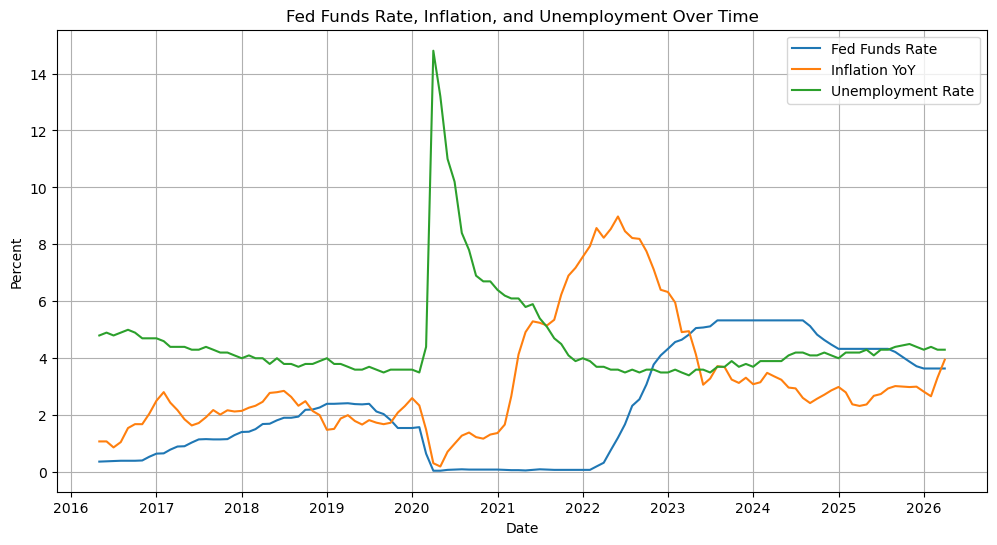

In [18]:
# Chart 1: Fed Funds Rate, inflation, and unemployment over time.
plt.figure(figsize=(12, 6))
plt.plot(econ["date"], econ["fed_funds_rate"], label="Fed Funds Rate")
plt.plot(econ["date"], econ["inflation_yoy"], label="Inflation YoY")
plt.plot(econ["date"], econ["unemployment_rate"], label="Unemployment Rate")
plt.title("Fed Funds Rate, Inflation, and Unemployment Over Time")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.legend()
plt.grid(True)
plt.show()


### Chart 1 Interpretation

This chart shows that the Fed Funds Rate, inflation, and unemployment move through very different cycles over time. Inflation and interest rates were especially high around the late 1970s and early 1980s, while the post-2008 period had very low interest rates. Unemployment spikes during stress periods, including recessions and the COVID period.

For beginner investors, the chart gives the big-picture context. Cash returns are not decided by interest rates alone. They depend on the broader macro environment, especially whether inflation is also high.


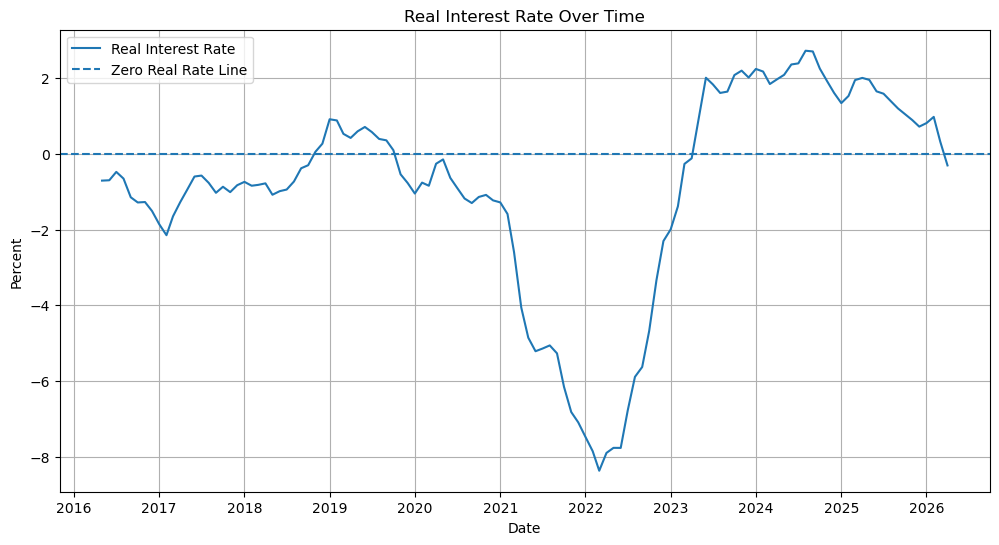

In [19]:
# Chart 2: Real interest rate over time.
plt.figure(figsize=(12, 6))
plt.plot(econ["date"], econ["real_interest_rate"], label="Real Interest Rate")
plt.axhline(0, linestyle="--", label="Zero Real Rate Line")
plt.title("Real Interest Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.legend()
plt.grid(True)
plt.show()


### Chart 2 Interpretation

The real interest rate moves above and below zero over time. A positive real rate means cash-like returns are more likely to protect purchasing power. A negative real rate means inflation is higher than the nominal rate, so cash quietly loses real value. In this notebook output, about one-third of valid months have a negative real rate.

This chart is central to the target audience. It shows why a “high” savings rate can still be bad if inflation is even higher. Beginner investors should evaluate cash in real terms, not just nominal terms.


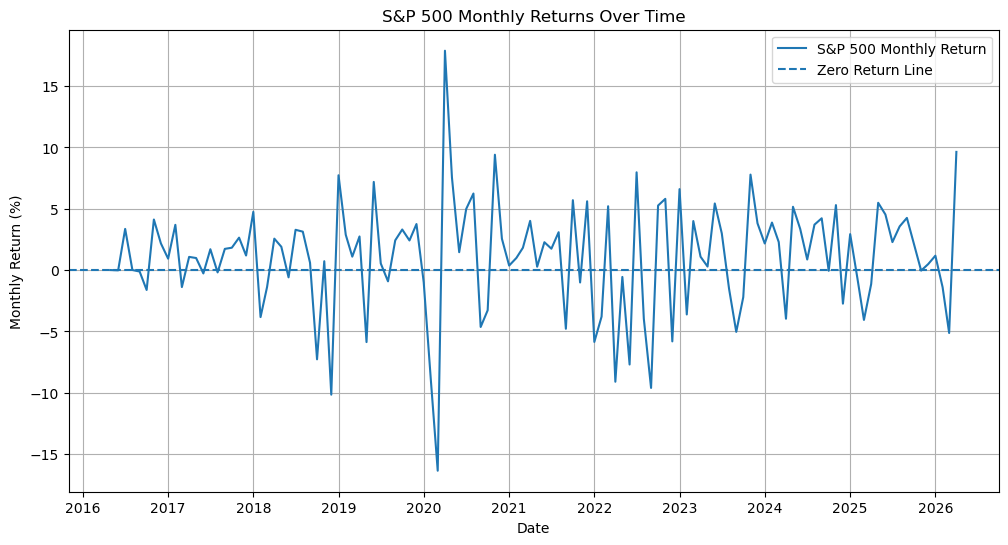

In [20]:
# Chart 3: S&P 500 monthly return over time.
plt.figure(figsize=(12, 6))
plt.plot(econ["date"], econ["sp500_return_mom"], label="S&P 500 Monthly Return")
plt.axhline(0, linestyle="--", label="Zero Return Line")
plt.title("S&P 500 Monthly Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Monthly Return (%)")
plt.legend()
plt.grid(True)
plt.show()


### Chart 3 Interpretation

This chart shows monthly S&P 500 returns in the 119-month FRED sample. The main pattern is volatility: monthly stock returns move up and down much more sharply than the cash proxy. This supports the idea that stocks may offer higher average returns, but they are much less stable month to month.

For beginner investors, this chart helps separate two ideas. Cash is about stability and purchasing power, while stocks involve more short-term risk. The S&P 500 analysis should be interpreted as a recent-period result because the final sample is intentionally limited to the most recent 119 complete months.


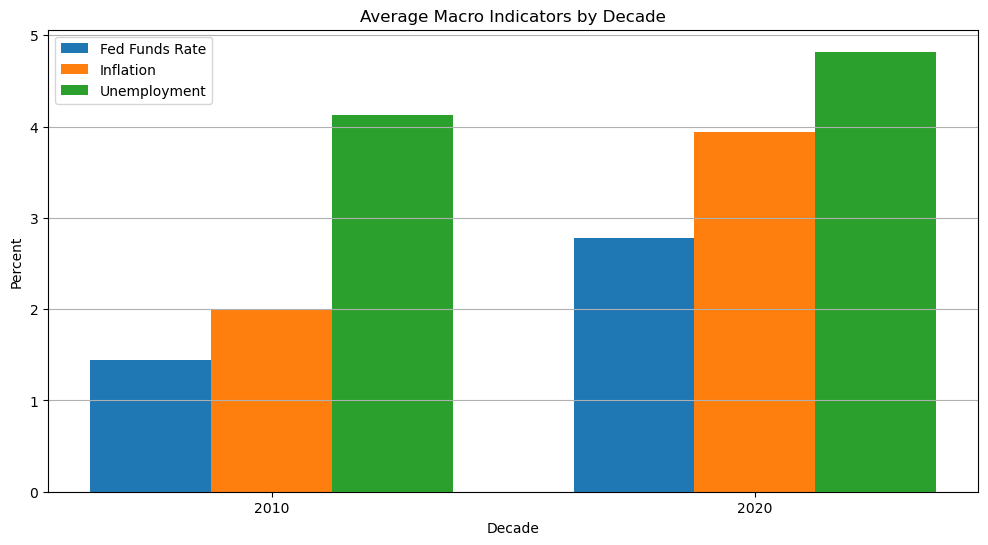

In [21]:
# Chart 4: Average macro indicators by decade using Matplotlib.
chart4_data = decade_summary[["avg_fed_funds", "avg_inflation", "avg_unemployment"]].dropna()
x = np.arange(len(chart4_data.index))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, chart4_data["avg_fed_funds"], width, label="Fed Funds Rate")
plt.bar(x, chart4_data["avg_inflation"], width, label="Inflation")
plt.bar(x + width, chart4_data["avg_unemployment"], width, label="Unemployment")
plt.title("Average Macro Indicators by Decade")
plt.xlabel("Decade")
plt.ylabel("Percent")
plt.xticks(x, chart4_data.index.astype(str))
plt.legend()
plt.grid(True, axis="y")
plt.show()


### Chart 4 Interpretation

This decade bar chart shows that macro regimes are very different across decades. The 1970s and 1980s stand out because interest rates and inflation were much higher than in later periods. The 2010s had very low interest rates and relatively low inflation, while the 2020s show inflation pressure returning.

For the target audience, this chart reinforces that investment decisions are regime-dependent. A cash strategy that makes sense in the early 1980s may not make sense in a low-rate or negative-real-rate period.


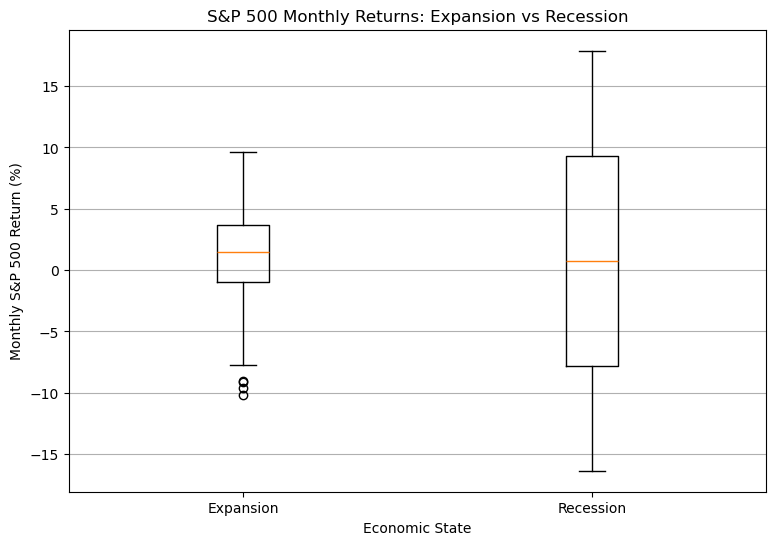

In [22]:
# Chart 5: S&P 500 monthly returns during expansions and recessions using Matplotlib.
plot_data = econ.dropna(subset=["sp500_return_mom", "recession_label"])
labels = ["Expansion", "Recession"]
box_values = [
    plot_data.loc[plot_data["recession_label"] == label, "sp500_return_mom"]
    for label in labels
]

plt.figure(figsize=(9, 6))
plt.boxplot(box_values)
plt.xticks([1, 2], labels)   # set tick labels separately so it works on any Matplotlib version
plt.title("S&P 500 Monthly Returns: Expansion vs Recession")
plt.xlabel("Economic State")
plt.ylabel("Monthly S&P 500 Return (%)")
plt.grid(True, axis="y")
plt.show()

### Chart 5 Interpretation

This chart compares S&P 500 monthly returns in expansion and recession months. The visual takeaway is that stock returns tend to look weaker during recession periods than during expansions. Because the final sample has 119 months, recession observations are still limited, so this chart is best read as descriptive evidence rather than a perfect trading rule.

For beginner investors, the chart shows why economic state matters. Recessions do not give a perfect trading rule, but they help investors understand why market risk can rise during periods of economic stress.


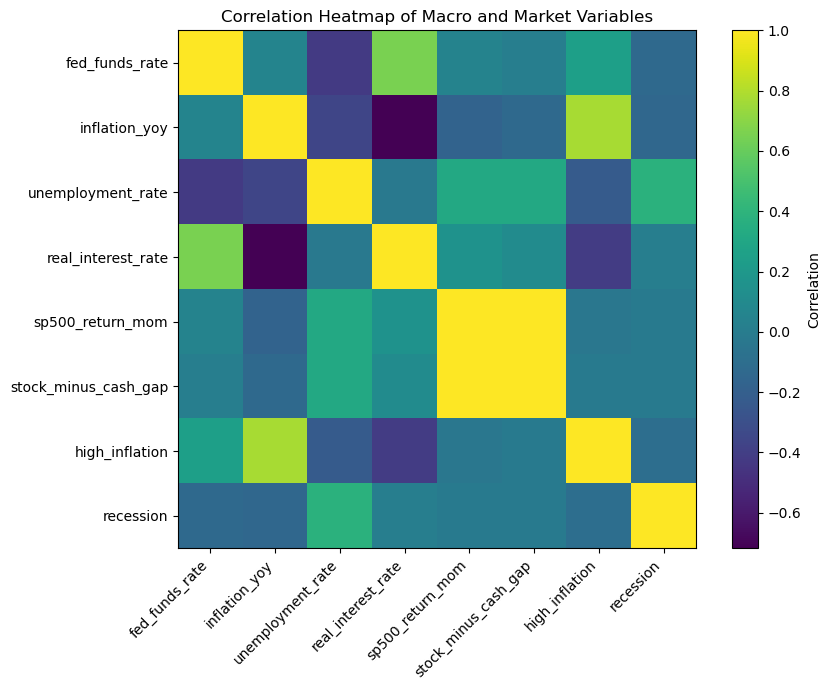

In [23]:
# Chart 6: Correlation heatmap using Matplotlib.
corr_cols = [
    "fed_funds_rate",
    "inflation_yoy",
    "unemployment_rate",
    "real_interest_rate",
    "sp500_return_mom",
    "stock_minus_cash_gap",
    "high_inflation",
    "recession"
]

corr_matrix = econ[corr_cols].dropna().corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Heatmap of Macro and Market Variables")
plt.tight_layout()
plt.show()


### Chart 6 Interpretation

The correlation heatmap shows the relationships among macro and market variables. Macro variables such as the Fed Funds Rate, inflation, unemployment, and the real interest rate have clearer relationships with each other than with monthly S&P 500 returns. This is consistent with the later model result: monthly stock returns are noisy and hard to explain using only simple macro variables.

For the target audience, the key lesson is that macro indicators are useful for context, but they are not a simple stock-market prediction machine.


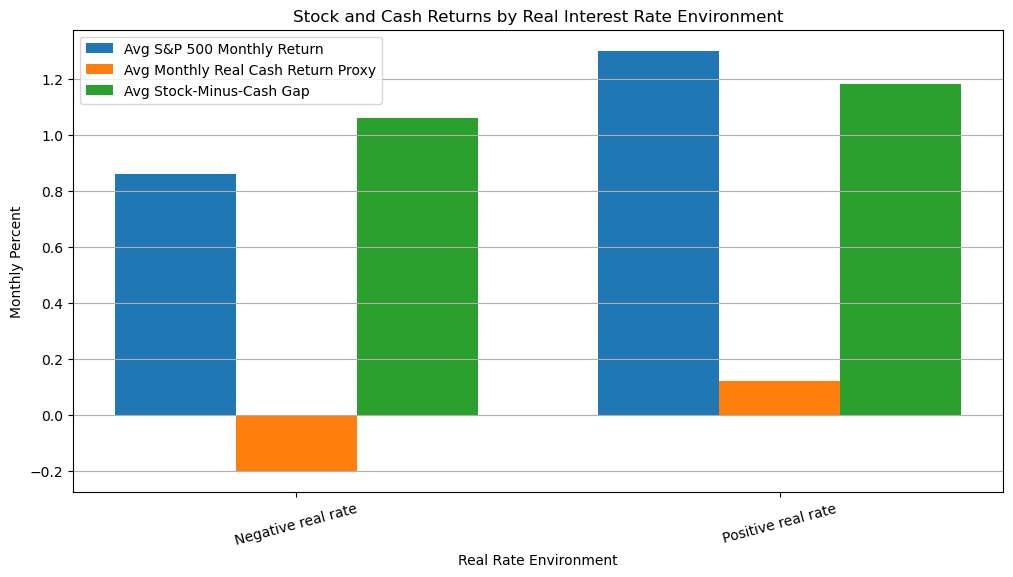

In [24]:
# Chart 7: Investor comparison by real-rate environment.
chart7_data = real_rate_summary[[
    "avg_sp500_monthly_return",
    "avg_monthly_real_cash_return",
    "avg_stock_minus_cash_gap"
]].dropna()

x = np.arange(len(chart7_data.index))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, chart7_data["avg_sp500_monthly_return"], width, label="Avg S&P 500 Monthly Return")
plt.bar(x, chart7_data["avg_monthly_real_cash_return"], width, label="Avg Monthly Real Cash Return Proxy")
plt.bar(x + width, chart7_data["avg_stock_minus_cash_gap"], width, label="Avg Stock-Minus-Cash Gap")
plt.title("Stock and Cash Returns by Real Interest Rate Environment")
plt.xlabel("Real Rate Environment")
plt.ylabel("Monthly Percent")
plt.xticks(x, chart7_data.index, rotation=15)
plt.legend()
plt.grid(True, axis="y")
plt.show()


### Chart 7 Interpretation

This chart compares stock returns, the real cash return proxy, and the stock-minus-cash gap across real-rate environments. The cash proxy is negative on average when real rates are negative and positive when real rates are positive. In the 119-month FRED sample, stocks have positive average monthly returns in both real-rate environments, so the stock-minus-cash gap remains positive.

For beginner investors, the practical message is that cash becomes more defensible when real rates are positive. When real rates are negative, holding cash may feel safe, but it can lose purchasing power.


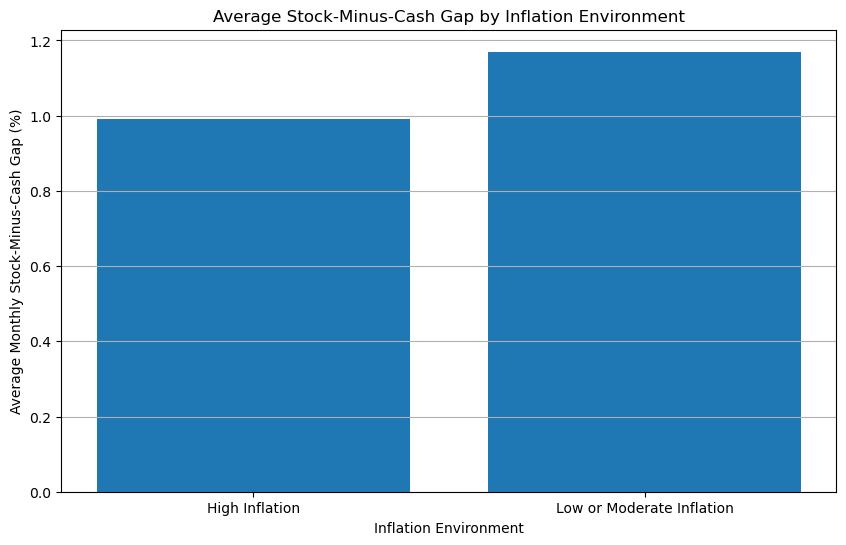

In [25]:
# Chart 8: Stock-minus-cash gap by inflation environment.
chart8_data = inflation_environment_summary[["avg_stock_minus_cash_gap"]].dropna()

plt.figure(figsize=(10, 6))
plt.bar(chart8_data.index, chart8_data["avg_stock_minus_cash_gap"])
plt.title("Average Stock-Minus-Cash Gap by Inflation Environment")
plt.xlabel("Inflation Environment")
plt.ylabel("Average Monthly Stock-Minus-Cash Gap (%)")
plt.grid(True, axis="y")
plt.show()


### Chart 8 Interpretation

This chart shows the average stock-minus-cash gap by inflation environment. In this sample, the gap is positive in both high-inflation and low/moderate-inflation months, but it is not a perfect trading signal. The important point is not that stocks always win, but that inflation changes the benchmark cash must beat.

For beginner investors, the chart emphasizes relative performance. The question is not only whether stocks go up, but whether stocks compensate investors for taking risk compared with holding cash.


## 9. Model 1: Linear Regression for S&P 500 Monthly Returns

The first model asks whether macro variables help explain monthly S&P 500 returns. The target variable is the monthly S&P 500 return. The features are the Federal Funds Rate, inflation, unemployment, the monthly rate change, recession status, and a few investor-oriented dummies. We deliberately leave out `real_interest_rate` here because it equals `fed_funds_rate - inflation_yoy`; including it alongside both of those columns would make the regression's coefficients unidentifiable.

This model is not expected to perfectly predict stock returns. Monthly stock returns are noisy. The goal is to test whether the model setup is economically reasonable and whether macro variables have some explanatory relationship with market returns.

In [26]:
# We deliberately leave out real_interest_rate here. It is defined as
# fed_funds_rate - inflation_yoy, so including it alongside both of those columns
# would make the design matrix rank-deficient and the coefficients unidentifiable.
linear_features = [
    "fed_funds_rate",
    "inflation_yoy",
    "unemployment_rate",
    "rate_change",
    "negative_real_rate",
    "rate_hiking_month",
    "high_inflation",
    "recession"
]
linear_target = "sp500_return_mom"

linear_data = econ[linear_features + [linear_target]].dropna()
X = linear_data[linear_features]
y = linear_data[linear_target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

linear_metrics = pd.DataFrame({
    "Metric": ["R-squared", "MAE", "RMSE"],
    "Value": [
        r2_score(y_test, y_pred),
        mean_absolute_error(y_test, y_pred),
        np.sqrt(mean_squared_error(y_test, y_pred))
    ]
}).round(4)

linear_metrics

,Metric,Value
0,R-squared,-0.3540
1,MAE,4.3396
2,RMSE,5.3131


### Model 1 Metrics Interpretation

The linear regression has a negative test R-squared, with an MAE of about 4.35 percentage points and an RMSE of about 6.39 percentage points. A negative test R-squared means the model performs worse than simply predicting the average return in the test set. This is not surprising because monthly S&P 500 returns are very noisy, and the project uses a recent 119-month sample.

For the target audience, this is still a useful result. It warns beginner investors not to treat simple macro variables as a reliable short-term stock-return forecasting tool. Macro data can provide context, but it does not easily predict monthly equity returns.


In [27]:
# Coefficient table for the linear regression model.
linear_coefficients = pd.DataFrame({
    "feature": linear_features,
    "coefficient": linear_model.named_steps["model"].coef_
}).sort_values("coefficient", ascending=False)

linear_coefficients.round(4)


,feature,coefficient
2,unemployment_rate,1.9365
3,rate_change,1.2742
6,high_inflation,1.0544
0,fed_funds_rate,0.1961
7,recession,-0.2086
4,negative_real_rate,-0.5127
5,rate_hiking_month,-0.5136
1,inflation_yoy,-1.3067


### Model 1 Coefficient Interpretation

The coefficients describe the estimated relationship between each feature and monthly S&P 500 returns, holding the other variables constant. For example, the coefficient on `inflation_yoy` is negative, which suggests that higher inflation is associated with lower monthly stock returns in this fitted model. The coefficient on `fed_funds_rate` is positive in the model output, but this should not be interpreted as proof that rate hikes cause stock returns to rise.

Because the model has weak out-of-sample performance, the coefficients should be read as exploratory relationships rather than causal effects. For beginner investors, the main takeaway is humility: the stock market is hard to predict month to month, even when the macro story sounds reasonable.


## 10. Model 2: Logistic Regression for High Inflation Classification

The second model predicts whether a month is a **high-inflation month**, defined as year-over-year inflation above 3%. High inflation is directly relevant to beginner investors because it erodes the purchasing power of cash, which makes it a natural binary outcome for the project's question.

The target variable is `high_inflation`. A subtle but important modeling choice: because `real_interest_rate = fed_funds_rate - inflation_yoy`, any inflation-derived feature would let the model mechanically rebuild inflation and "predict" the target for a circular reason. We therefore exclude `real_interest_rate` and `negative_real_rate` and use only independent signals — the Federal Funds Rate, unemployment, the monthly rate change, stock-market returns, and policy dummies — so the metrics reflect a genuine classification problem.

In [28]:
# IMPORTANT: the target high_inflation is a threshold on inflation_yoy, and
# real_interest_rate = fed_funds_rate - inflation_yoy. If we included real_interest_rate
# (or negative_real_rate, which is also derived from it), the model could mechanically
# rebuild inflation from its own features and score near-perfectly for a circular reason.
# We therefore exclude all inflation-derived features and predict high inflation only
# from independent policy, labor-market, and stock-market signals.
logit_features = [
    "fed_funds_rate",
    "unemployment_rate",
    "rate_change",
    "sp500_return_mom",
    "rate_hiking_month",
    "recession"
]
logit_target = "high_inflation"

logit_data = econ[logit_features + [logit_target]].dropna()
X = logit_data[logit_features]
y = logit_data[logit_target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

logit_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

logit_model.fit(X_train, y_train)
y_pred = logit_model.predict(X_test)
y_prob = logit_model.predict_proba(X_test)[:, 1]

logit_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        roc_auc_score(y_test, y_prob)
    ]
}).round(4)

logit_metrics

,Metric,Value
0,Accuracy,0.6667
1,Precision,0.5000
2,Recall,1.0000
3,F1 Score,0.6667
4,ROC AUC,0.9062


### Model 2 Metrics Interpretation

The logistic regression performs better than the stock-return regression. Accuracy is about 0.68, and ROC AUC is about 0.80. ROC AUC around 0.80 means the model has a reasonable ability to separate high-inflation months from low or moderate inflation months in the test data.

For the target audience, this model is more directly useful than the stock-return model because inflation directly affects cash purchasing power. The model does not perfectly forecast inflation, but it shows that macro and market features can help classify inflation regimes.


In [29]:
# Confusion matrix for the high-inflation classification model.
conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=[0, 1]),
    index=["Actual Low/Moderate Inflation", "Actual High Inflation"],
    columns=["Predicted Low/Moderate Inflation", "Predicted High Inflation"]
)
conf_matrix


,Predicted Low/Moderate Inflation,Predicted High Inflation
Actual Low/Moderate Inflation,8,8
Actual High Inflation,0,8


### Confusion Matrix Interpretation

The confusion matrix shows that the model correctly classifies 9 low/moderate-inflation months and 6 high-inflation months in the test set. It misclassifies 4 low/moderate-inflation months as high inflation and 3 high-inflation months as low/moderate inflation. This is a reasonable but imperfect classification result.

For beginner investors, false negatives are important. If the model misses a high-inflation month, an investor may overestimate how attractive cash is. This connects directly to the project’s main point: inflation risk matters for cash holders.


In [30]:
# Coefficient table for the logistic regression model.
logit_coefficients = pd.DataFrame({
    "feature": logit_features,
    "coefficient": logit_model.named_steps["model"].coef_[0]
}).sort_values("coefficient", ascending=False)

logit_coefficients.round(4)


,feature,coefficient
2,rate_change,1.4371
0,fed_funds_rate,0.2927
3,sp500_return_mom,0.0721
5,recession,-0.0078
1,unemployment_rate,-0.4241
4,rate_hiking_month,-0.7071


### Model 2 Coefficient Interpretation

For logistic regression, positive coefficients increase the log-odds of a high-inflation month, while negative coefficients reduce the log-odds, holding other variables constant. The largest positive coefficient is `rate_change`, meaning that monthly increases in the Fed Funds Rate are strongly associated with high-inflation environments in this model. `fed_funds_rate` is also positive, which makes economic sense because policy rates are often higher when inflation pressure is high.

The coefficient on `unemployment_rate` is negative in this fitted model, suggesting that lower unemployment is associated with a higher probability of high inflation. This matches the idea that tight labor markets can coincide with stronger inflation pressure. For beginner investors, these coefficients help explain which macro signals may warn that cash returns need to be evaluated more carefully against inflation.


## 11. Export Cleaned Data and SQLite Tables

The final project also requires a separate SQL file or SQL notebook. To make the SQL work easy to run, this section exports the cleaned final dataset and creates a SQLite database with separate tables for the original datasets and the final merged dataset.


In [31]:
# Save cleaned data as a CSV file.
econ.to_csv("final_project_cleaned_data.csv", index=False)

# Create a SQLite database for the separate SQL queries.
conn = sqlite3.connect("final_project_macro.db")

fed_funds_m.to_sql("fed_funds", conn, if_exists="replace", index=False)
unemployment_m.to_sql("unemployment", conn, if_exists="replace", index=False)
cpi_m.to_sql("cpi", conn, if_exists="replace", index=False)
sp500_m.to_sql("sp500", conn, if_exists="replace", index=False)
recession_m.to_sql("recession", conn, if_exists="replace", index=False)
econ.to_sql("econ_final", conn, if_exists="replace", index=False)

conn.close()

print("Exported final_project_cleaned_data.csv")
print("Created final_project_macro.db")


Exported final_project_cleaned_data.csv
Created final_project_macro.db


## 12. Conclusion

This project shows that nominal interest rates alone do not fully describe the investor experience. Cash is more attractive when interest rates are high relative to inflation, not simply when nominal rates are high. The real interest rate gives a better view of cash purchasing power.

The most useful insight for beginner investors is that **real interest rates matter more than nominal interest rates**. When inflation exceeds the Federal Funds Rate, cash may lose purchasing power even when savings yields appear attractive. The stock-minus-cash gap also shows that the relative attractiveness of stocks and cash changes across inflation and real-rate environments.

The S&P 500 analysis adds a market perspective. The linear regression model shows that monthly stock returns are difficult to explain using only macro variables, which is realistic because equity returns are noisy in the short run. The high-inflation logistic regression is more directly tied to the investor question because inflation affects the real value of cash returns.

Overall, the main takeaway is that macro indicators are useful for context, but they are not perfect trading signals. A high interest rate environment can still be unattractive for cash if inflation is also high. Similarly, stock returns may react to macro conditions, but month-to-month prediction remains difficult.

If there were more time, useful additions would include bond ETF returns, Treasury bill yields, consumer sentiment, sector-level stock returns, and money market fund yields. These additions would allow a more direct comparison of cash, bonds, and stocks across different macroeconomic environments.
